# Economic charting with `ggplot2` in R

In [6]:
# Load necessary libraries
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(magrittr))
suppressPackageStartupMessages(library(lubridate))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(gridExtra))

In [7]:
# Set plot dimensions to 3.9*2 x 3.2 inches
options(repr.plot.width = 3.9, repr.plot.height = 3.2)  # in inches

# Dumbbell plot

I will plot the state-level changes in the reported median age between the 2010 census and the 2020 census using the Census Bureau's API via the `censusapi` library. The documentation for all the Census Bureau's API datasets can be found [here](https://www.census.gov/data/developers/data-sets.html).

Pull in data from the 2010 census. **Summary File 1** data fields can be found [here](https://api.census.gov/data/2010/dec/sf1/variables.html). I pull <ins>P013001</ins> which is labeled "Median age!!Both sexes" in the 2010 SF1 API Variables.

In [8]:
suppressPackageStartupMessages(library(censusapi))

In [9]:
data2010 <- getCensus(
    name = "dec/sf1",
    vintage = 2010,
    vars = c("NAME", "P013001"), # H010001 
    region = "state:*")
# nrow(data2010)
data2010 %>% arrange(desc(P013001)) %>% head()

,state,NAME,P013001
,<chr>,<chr>,<dbl>
1,23,Maine,42.7
2,50,Vermont,41.5
3,54,West Virginia,41.3
4,33,New Hampshire,41.1
5,12,Florida,40.7
6,42,Pennsylvania,40.1


Pull in data from the 2020 census. **Demographic Profile** data fields can be found [here](https://api.census.gov/data/2020/dec/dp/variables.html). I pull <ins>DP1_0073C</ins> which is labeled "Count!!MEDIAN AGE BY SEX!!Both sexes" in the 2020 DP API Variables.

In [10]:
data2020 <- getCensus(
    name = "dec/dp",
    vintage = 2020,
    vars = c("NAME", "DP1_0073C"), 
    region = "state:*")
# nrow(data2020)
head(data2020 %>% arrange(desc(DP1_0073C))) %>% head()

,state,NAME,DP1_0073C
,<chr>,<chr>,<dbl>
1,72,Puerto Rico,45.2
2,23,Maine,45.1
3,33,New Hampshire,43.6
4,50,Vermont,43.5
5,12,Florida,43.0
6,54,West Virginia,42.9


Merge data from the 2010 census with data from the 2020 census. Calculate the state-level difference between the median age reported in 2010 and 2020.

In [11]:
df <- full_join(data2010, data2020, by = c("state", "NAME"))
df <- df %>% mutate(chg=abs(DP1_0073C-P013001)) %>%
arrange(desc(chg))
head(df)

,state,NAME,P013001,DP1_0073C,chg
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,72,Puerto Rico,36.9,45.2,8.3
2,04,Arizona,35.9,38.9,3.0
3,28,Mississippi,36.0,39.0,3.0
4,45,South Carolina,37.9,40.5,2.6
5,33,New Hampshire,41.1,43.6,2.5
6,35,New Mexico,36.7,39.2,2.5


Take the 10 U.S. states and territories which saw the largest change in median age over 10 years.

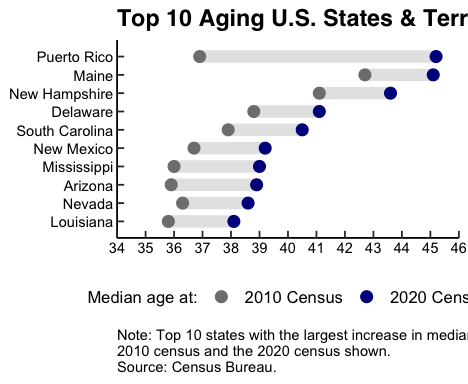

In [12]:
df_long <- df %>% slice_max(order_by = chg, n = 10) %>% select(-chg) %>% pivot_longer(-c(state, NAME))

neat_order <- (df %>% arrange(DP1_0073C))$NAME

aging <- df_long %>% 
  mutate(NAME = factor(NAME, levels = neat_order)) %>%
  ggplot(aes(x=value,y=NAME)) +  
  geom_line(aes(group=NAME), color="gray90", linewidth=3.5) +
  geom_point(aes(color=name), size=3) + 
  theme_classic() +
  theme(
    legend.position = "bottom",
    plot.title = element_text(family = "Helvetica", face = "bold", size = 14),
    plot.subtitle = element_text(hjust = 0, size = 10),
    axis.text = element_text(color = "black"),
    axis.ticks.length = unit(-0.15, "cm"),
    plot.caption = element_text(hjust = 0),
    legend.text = element_text(size = 10),
    legend.title = element_text(size = 10)
    ) +
  scale_color_manual(
    name="Median age at:", 
    breaks=c("P013001", "DP1_0073C"),
    values=c("DP1_0073C"="darkblue", "P013001"="gray50"),
    labels=c("DP1_0073C"="2020 Census","P013001"="2010 Census")
    ) +
  scale_x_continuous(
    limits=c(34, 46),
    breaks = seq(30, 46, 1),
    expand = c(0, 0)
    ) +
    scale_y_discrete(
      expand=c(0.1,0)
    ) +
  xlab(NULL) + ylab(NULL) +
  labs(
    title = "Top 10 Aging U.S. States & Territories", 
    # subtitle = "Median Age", 
    caption = paste0(
      "Note: Top 10 states with the largest increase in median age between the",
      "\n2010 census and the 2020 census shown.",
      "\nSource: Census Bureau.")
    )

aging

ggsave("../plots/aging.png", plot = aging, width = 3.9*1.25, height = 3.2+(0.13*4), units = "in", dpi = 300)